In [59]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the Excel file
# file_path = 'dv0_witoutstraw.xlsx'  
file_path = 'dv0_withoutstraw_sipCAdded.xlsx' # Use the correct path for your environment
data = pd.read_excel(file_path)
# print("Columns in the dataset:")
# print(data.columns.tolist())
# Display the first few rows of the dataset to understand its structure
# print("Original Data Sample:")

df = data[data['Label'] == 1]

df['Gender'] = df["Gender"].map({"Male": 1, "Female": 0})

df["Container_Weight"] = df["Container_Weight"].map({
    7.7: 0,
    10.6: 1,
    10.9: 1,  
    12.7: 2,
    19.8: 3,
    359: 4
})
# df["Container_Weight"] = df["Container_Weight"].map({
#     7.7: 0,   # First type.  water plastic bottle
#     10.6: 1,  # Second type. paper cup 
#     10.9: 2,  # Changed this to represent a distinct type- paper cup
#     12.7: 3,  # Third type. cup plastic
#     19.8: 4,  # Fourth type bottle coke
#     359: 5    # Fifth type mug
# })
df["Label"] = df["Label"].map({"Drinking": 1, "Not_Drinking": 0})

df['temp'] = df ['temp'].map({'h':2, 'c':0, 'n': 1})
# print(data.head())
# Group by Participant_ID and sip_id to count time steps and extract dV and Label
grouped_data = df.groupby(['Participant_ID', 'sip_id']).agg(
    time_steps=('sip_id', 'size'),  # Count of rows (time steps)
    dV=('dV', 'first'),  # Taking the first dV value for each group
    Gender=('Gender', 'first'), 
    temp=('temp', 'first') ,
    Container_Weight=('Container_Weight', 'first'),
    Label=('Label', 'first')  # Assuming the label is consistent, take the first
).reset_index()

# Remove rows where dV is zero
grouped_data = grouped_data[grouped_data['dV'] != 0]
# Merge SIP_TIME back to the grouped data
# grouped_data = pd.merge(grouped_data, sip_counts, on='sip_id', how='left').fillna(0)
# grouped_data['SIP_TIME'] = grouped_data['SIP_TIME'].astype(int)
# Display the grouped data before creating X and y
print("\nGrouped Data Sample:")
print(grouped_data.head(200))
# grouped_data.to_excel('dv0_witoutstraw_final.xlsx')
# Prepare features (X) and target (y)
# X = grouped_data[['time_steps','Gender', 'Container_Weight','temp', 'sip_id']]  # Features
X = grouped_data[['time_steps','Container_Weight']]  # Features
y = grouped_data['dV']             # Target variable

# Display X and y before proceeding
print("\nFeatures (X):")
print(X.head(50))
print("\nTarget (y):")
print(y.head(50))

# Split the data into training and testing sets (optional)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now you can proceed with training your model using X and y as needed


Grouped Data Sample:
     Participant_ID  sip_id  time_steps   dV  Gender  temp  Container_Weight  \
0                 1       1          23  100       1     1                 2   
1                 1       2          19   80       1     1                 2   
2                 1       3          13   60       1     1                 2   
3                 1       4          11   40       1     1                 2   
4                 2       1          11   20       1     1                 2   
..              ...     ...         ...  ...     ...   ...               ...   
126              26       1          24   20       1     1                 0   
127              26       2          60   40       1     1                 0   
128              26       3         113   60       1     1                 0   
129              26       4         171   80       1     1                 0   
130              26       5         301  100       1     1                 0   

     Label  
0   

/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_6245/1226465248.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df["Gender"].map({"Male": 1, "Female": 0})
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_6245/1226465248.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Container_Weight"] = df["Container_Weight"].map({
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_6245/1226465248.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy

In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the Excel file
# file_path = 'dv0_witoutstraw.xlsx'  
file_path = 'previous_dv0_withoutstraw_sipCAdded.xlsx' # Use the correct path for your environment
data = pd.read_excel(file_path)
# print("Columns in the dataset:")
# print(data.columns.tolist())
# Display the first few rows of the dataset to understand its structure
# print("Original Data Sample:")

df = data[data['Label'] == 1]
df['Gender'] = df["Gender"].map({"Male": 1, "Female": 0})

df["Container_Weight"] = df["Container_Weight"].map({
    7.7: 0,
    10.6: 1,
    10.9: 1,  
    12.7: 2,
    19.8: 3,
    359: 4
})
# df["Container_Weight"] = df["Container_Weight"].map({
#     7.7: 0,   # First type.  water plastic bottle
#     10.6: 1,  # Second type. paper cup 
#     10.9: 2,  # Changed this to represent a distinct type- paper cup
#     12.7: 3,  # Third type. cup plastic
#     19.8: 4,  # Fourth type bottle coke
#     359: 5    # Fifth type mug
# })
df["Label"] = df["Label"].map({"Drinking": 1, "Not_Drinking": 0})
df['temp'] = df ['temp'].map({'h':2, 'c':0, 'n': 1})
# print(data.head())
# Group by Participant_ID and sip_id to count time steps and extract dV and Label
grouped_data = df.groupby(['Participant_ID', 'sip_id']).agg(
    time_steps=('sip_id', 'size'),  # Count of rows (time steps)
    dV=('dV', 'first'),  # Taking the first dV value for each group
    Gender=('Gender', 'first'), 
    temp=('temp', 'first') ,
    Container_Weight=('Container_Weight', 'first'),
    Label=('Label', 'first')  # Assuming the label is consistent, take the first
).reset_index()

# Remove rows where dV is zero
grouped_data = grouped_data[grouped_data['dV'] != 0]
# Merge SIP_TIME back to the grouped data
# grouped_data = pd.merge(grouped_data, sip_counts, on='sip_id', how='left').fillna(0)
# grouped_data['SIP_TIME'] = grouped_data['SIP_TIME'].astype(int)
# Display the grouped data before creating X and y
print("\nGrouped Data Sample:")
print(grouped_data.head(200))
# grouped_data.to_excel('dv0_witoutstraw_final.xlsx')
# Prepare features (X) and target (y)
# X = grouped_data[['time_steps','Gender', 'Container_Weight','temp', 'sip_id']]  # Features
X_P = grouped_data[['time_steps','Container_Weight']]  # Features
y_P= grouped_data['dV']             # Target variable

# Display X and y before proceeding
print("\nFeatures (X):")
print(X.head(50))
print("\nTarget (y):")
print(y.head(50))

# Split the data into training and testing sets (optional)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now you can proceed with training your model using X and y as needed


Grouped Data Sample:
     Participant_ID  sip_id  time_steps          dV  Gender  temp  \
0                 6       1          26   69.904762       1     0   
1                 6       2          26   58.000000       1     0   
2                 6       3          27   61.904762       1     0   
3                 6       4          29   68.857143       1     0   
4                 6       5          23   44.571429       1     0   
..              ...     ...         ...         ...     ...   ...   
195              36      16          16   36.630754       1     0   
196              36      17          14   28.795299       1     0   
197              37       1          20  129.300000       0     1   
198              37       2          23  160.200000       0     1   
199              37       3          22  141.600000       0     1   

     Container_Weight  Label  
0                   3    NaN  
1                   3    NaN  
2                   3    NaN  
3                   3    

/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_6245/888347338.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df["Gender"].map({"Male": 1, "Female": 0})
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_6245/888347338.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Container_Weight"] = df["Container_Weight"].map({
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_6245/888347338.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of

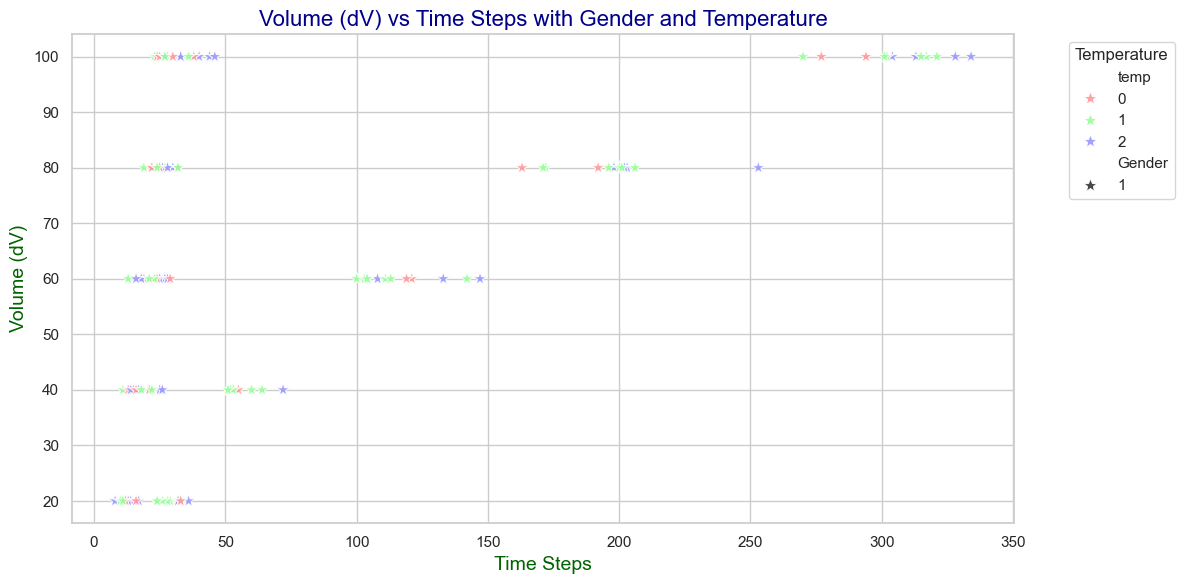

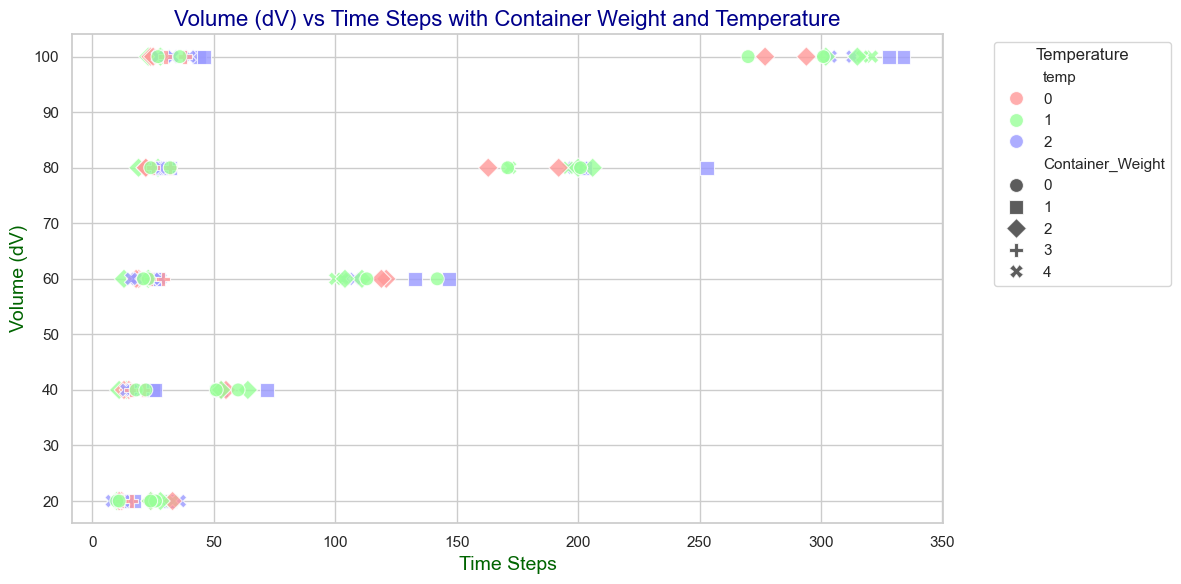

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Container Weight Color Palette with Distinct Colors
container_weight_palette = {
    0: '#1f77b4',   # Color for Container_Weight = 0
    1: '#ff7f0e',   # Color for Container_Weight = 1
    2: '#2ca02c',   # Color for Container_Weight = 2
    3: '#d62728',   # Color for Container_Weight = 3
    4: '#9467bd',   # Color for Container_Weight = 4
}

# Temperature Color Palette with Brighter Colors
temp_palette = {
    0: '#ff9999',  # Color for temp = 0 (h)
    1: '#99ff99',  # Color for temp = 1 (n)
    2: '#9999ff'   # Color for temp = 2 (c)
}

# Create distinct markers for Gender
markers = {0: "s", 1: "*"}  # 0: Female (square), 1: Male (star)

# Create a scatter plot of volume (dV) vs time_steps by gender
plt.figure(figsize=(12, 6))
sns.scatterplot(data=grouped_data, 
                x='time_steps', 
                y='dV', 
                hue='temp',               # Hue based on Temperature
                palette=temp_palette,     # Use the temp color palette
                style='Gender',           # Different markers for Gender
                markers=markers, 
                legend='full',
                s=100,                    # Increase marker size for visibility
                alpha=0.9,                # Adjust transparency
                edgecolor='w')            # Add edge color for better visibility

# Adding titles and labels with colors for visibility
plt.title("Volume (dV) vs Time Steps with Gender and Temperature", fontsize=16, color='darkblue')
plt.xlabel("Time Steps", fontsize=14, color='darkgreen')
plt.ylabel("Volume (dV)", fontsize=14, color='darkgreen')

# Customize the legend for better visibility
plt.legend(title='Temperature', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the first plot
plt.tight_layout()
plt.show()

# Create a new scatter plot of volume (dV) vs time_steps by container weight
plt.figure(figsize=(12, 6))

# Assign distinct markers for each container weight
container_markers = {0: "o", 1: "s", 2: "D", 3: "P", 4: "X"}  # Circle, Square, Diamond, Pentagon, X

# Scatter plot with Container Weight and Temperature
sns.scatterplot(data=grouped_data, 
                x='time_steps', 
                y='dV', 
                hue='temp',                # Hue based on Temperature
                palette=temp_palette,      # Use the temp color palette
                style='Container_Weight',  # Different markers for Container Weight
                markers=container_markers,  # Assign different markers
                legend='full',
                s=100,                    # Increase marker size for visibility
                alpha=0.8,                # Adjust transparency
                edgecolor='w')            # Add edge color for better visibility

# Adding titles and labels with colors for visibility
plt.title("Volume (dV) vs Time Steps with Container Weight and Temperature", fontsize=16, color='darkblue')
plt.xlabel("Time Steps", fontsize=14, color='darkgreen')
plt.ylabel("Volume (dV)", fontsize=14, color='darkgreen')

# Customize the legend for better visibility
plt.legend(title='Temperature', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the second plot
plt.tight_layout()
plt.show()

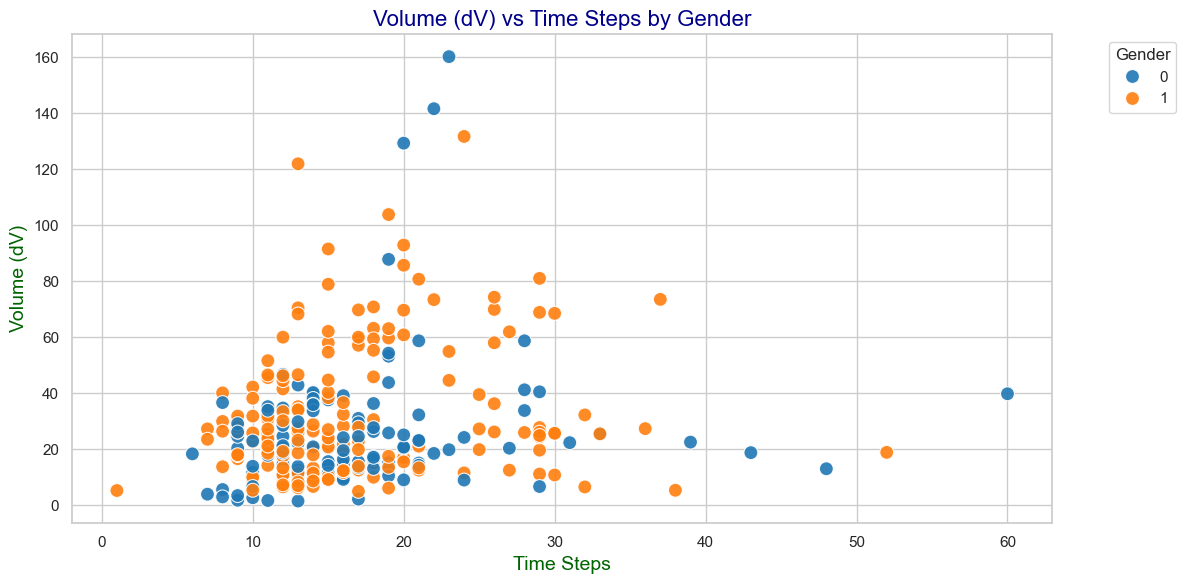


Gender Marker Mapping:
 - zero: Female
 - one: Male



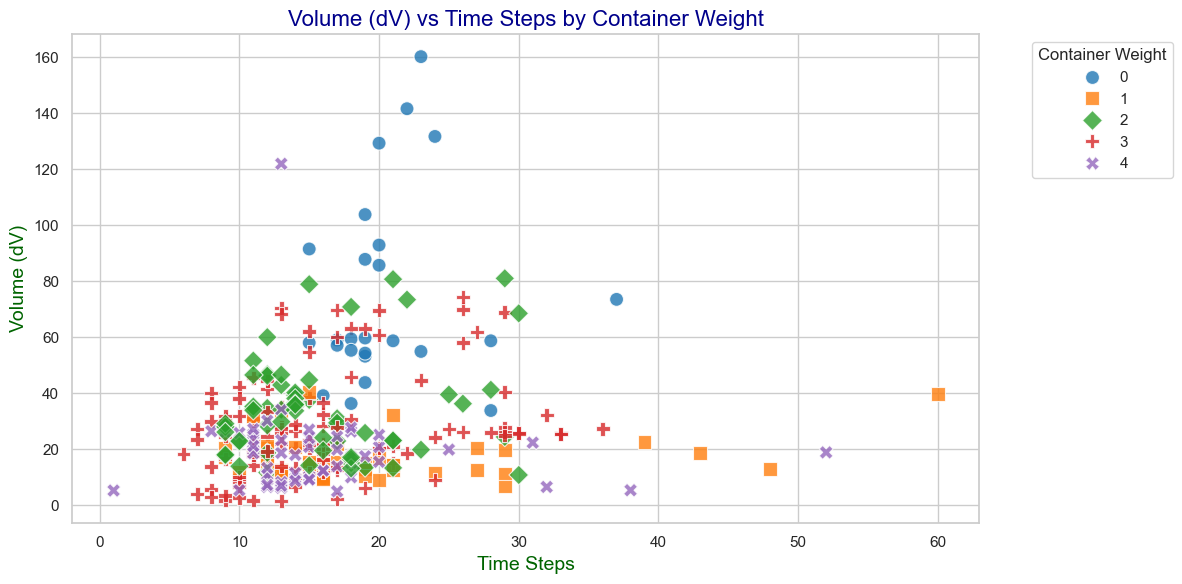


Container Weight Color Mapping:
 - Blue (#1f77b4): Weight 7.7
 - Orange (#ff7f0e): Weight 10.9
 - Green (#2ca02c): Weight 12.7
 - Red (#d62728): Weight 19.8
 - Purple (#9467bd): Weight 359


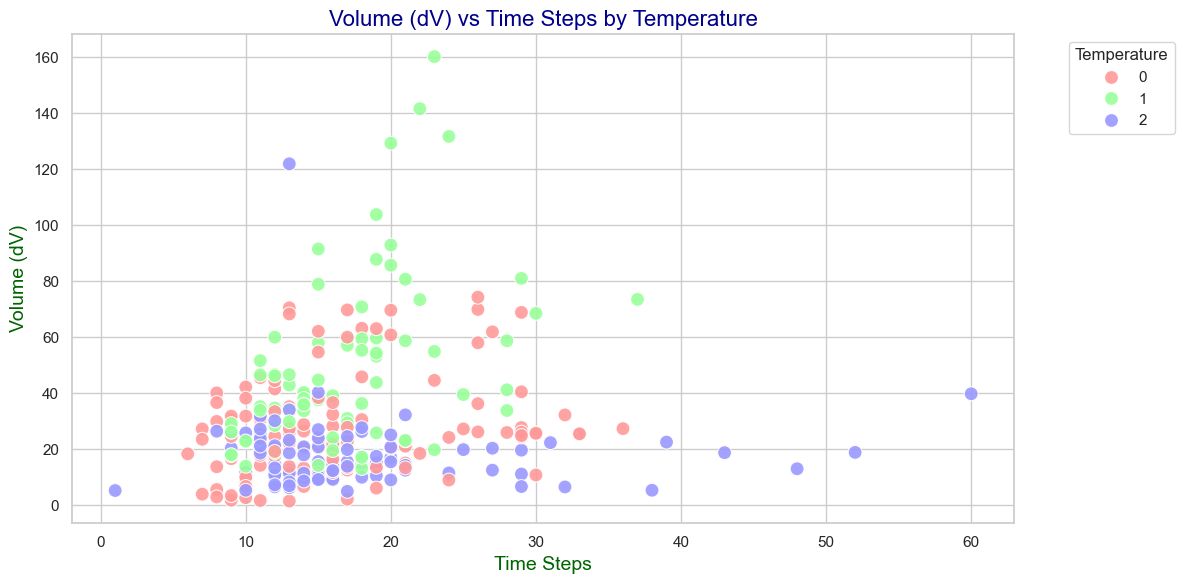

Temperature Color Mapping:
 - Red (#ff9999): Hot
 - Green (#99ff99): Normal
 - Blue (#9999ff): Cold


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Color Palette Definition
container_weight_palette = {
    0: '#1f77b4',   # Color for Container_Weight = 0 (7.7)
    1: '#ff7f0e',   # Color for Container_Weight = 1 (10.6)
    2: '#2ca02c',   # Color for Container_Weight = 2 (10.9)
    3: '#d62728',   # Color for Container_Weight = 3 (12.7)
    4: '#9467bd',   # Color for Container_Weight = 4 (19.8)
}

# Temperature Color Palette
temp_palette = {
    0: '#ff9999',  # Color for temp = 0 (Hot)
    1: '#99ff99',  # Color for temp = 1 (Normal)
    2: '#9999ff'   # Color for temp = 2 (Cold)
}

# Create distinct markers for Gender
gender_markers = {0: "s", 1: "*"}  # 0: Female (square), 1: Male (star)

# Plot 1: Volume (dV) vs Time Steps by Gender
plt.figure(figsize=(12, 6))
sns.scatterplot(data=grouped_data, 
                x='time_steps', 
                y='dV', 
                hue='Gender',              # Hue based on Gender
                palette={0: '#1f77b4', 1: '#ff7f0e'},  # Colors for Gender
                markers=gender_markers,    # Distinct markers for Gender
                legend='full',
                s=100,                     # Increase marker size for visibility
                alpha=0.9,                 # Adjust transparency
                edgecolor='w')             # Add edge color for better visibility

# Adding titles and labels for Gender Plot
plt.title("Volume (dV) vs Time Steps by Gender", fontsize=16, color='darkblue')
plt.xlabel("Time Steps", fontsize=14, color='darkgreen')
plt.ylabel("Volume (dV)", fontsize=14, color='darkgreen')

# Customize the legend for better visibility
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the Gender Plot
plt.tight_layout()
plt.show()
print("\nGender Marker Mapping:")  
print(" - zero: Female")  
print(" - one: Male\n")  
# Plot 2: Volume (dV) vs Time Steps by Container Weight
plt.figure(figsize=(12, 6))
# Distinct markers for Container Weight
container_markers = {0: "o", 1: "s", 2: "D", 3: "P", 4: "X"}  # Circle, Square, Diamond, Pentagon, X

# Scatter plot with Container Weight
sns.scatterplot(data=grouped_data, 
                x='time_steps', 
                y='dV', 
                hue='Container_Weight',     # Hue based on Container Weight
                palette=container_weight_palette,  # Use distinct colors for each weight
                style='Container_Weight',   # Different markers for each Container Weight
                markers=container_markers,   # Assign different markers
                legend='full',
                s=100,                     # Increase marker size for visibility
                alpha=0.8,                 # Adjust transparency
                edgecolor='w')             # Add edge color for better visibility

# Adding titles and labels for Container Weight Plot
plt.title("Volume (dV) vs Time Steps by Container Weight", fontsize=16, color='darkblue')
plt.xlabel("Time Steps", fontsize=14, color='darkgreen')
plt.ylabel("Volume (dV)", fontsize=14, color='darkgreen')

# Customize the legend for better visibility
plt.legend(title='Container Weight', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the Container Weight Plot
plt.tight_layout()
plt.show()
print("\nContainer Weight Color Mapping:")  
print(" - Blue (#1f77b4): Weight 7.7")  
print(" - Orange (#ff7f0e): Weight 10.9")  
print(" - Green (#2ca02c): Weight 12.7")  
print(" - Red (#d62728): Weight 19.8")  
print(" - Purple (#9467bd): Weight 359")  
# Plot 3: Volume (dV) vs Time Steps by Temperature
plt.figure(figsize=(12, 6))
# Scatter plot with Temperature
sns.scatterplot(data=grouped_data, 
                x='time_steps', 
                y='dV', 
                hue='temp',               # Hue based on Temperature
                palette=temp_palette,     # Use the temp color palette
                legend='full',
                s=100,                    # Increase marker size for visibility
                alpha=0.9,                # Adjust transparency
                edgecolor='w')            # Add edge color for better visibility

# Adding titles and labels for Temperature Plot
plt.title("Volume (dV) vs Time Steps by Temperature", fontsize=16, color='darkblue')
plt.xlabel("Time Steps", fontsize=14, color='darkgreen')
plt.ylabel("Volume (dV)", fontsize=14, color='darkgreen')

# Customize the legend for better visibility
plt.legend(title='Temperature', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the Temperature Plot
plt.tight_layout()
plt.show()
print("Temperature Color Mapping:")  
print(" - Red (#ff9999): Hot")  
print(" - Green (#99ff99): Normal")  
print(" - Blue (#9999ff): Cold")  




In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create a custom color palette for Container Weight
container_weight_palette = {
    0: '#1f77b4',  # Color for Container_Weight = 0
    1: '#ff7f0e',  # Color for Container_Weight = 1
    1: '#ff7f0e',  # Color for Container_Weight = 1
    2: '#2ca02c',  # Color for Container_Weight = 2
    3: '#d62728',  # Color for Container_Weight = 3
    4: '#9467bd',  # Color for Container_Weight = 4
}

# # Create a custom marker palette for Gender
# gender_palette = {"Male": '#1f77b4', "Female": '#ff7f0e'}

# Create a scatter plot of volume (dV) vs time_steps
plt.figure(figsize=(12, 6))

# Scatter plot for Container Weight
sns.scatterplot(data=grouped_data, 
                x='time_steps', y='dV', 
                hue='Container_Weight', 
                palette=container_weight_palette,
                style='Gender', 
                markers={"Male": "o", "Female": "s"},  # Assign different markers
                legend='full')

# Adding titles and labels with colors for visibility
plt.title("Volume (dV) vs Time Steps", fontsize=16, color='darkblue')
plt.xlabel("Time Steps", fontsize=14, color='darkgreen')
plt.ylabel("Volume (dV)", fontsize=14, color='darkgreen')

# Customize the legend for better visibility
plt.legend(title='Container Weight & Gender', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()

ValueError: These `markers` levels are missing values: {np.int64(0), np.int64(1)}

<Figure size 1200x600 with 0 Axes>

In [64]:
# Check for time_steps equal to zero
zero_time_steps_mask = grouped_data['dV'] == 0  # Creates a boolean mask
zero_time_steps_indices = grouped_data.index[zero_time_steps_mask].tolist()  # Get indices of rows where time_steps is zero
zero_time_steps_count = zero_time_steps_mask.sum()  # Count how many are True in the mask

# Display results
print(f"\nIndices where time_steps are 0: {zero_time_steps_indices}")
print(f"Total number of time_steps that are 0: {zero_time_steps_count}")


Indices where time_steps are 0: []
Total number of time_steps that are 0: 0


In [65]:
# Retrieve the records from grouped_data using the identified indices
zero_time_steps_records = grouped_data.loc[zero_time_steps_indices]

# Get the Participant_ID and sip_id
participant_ids_and_sip_ids = zero_time_steps_records[['Participant_ID', 'sip_id']]

# Display the result
print("\nRecords with zero time_steps:")
print(participant_ids_and_sip_ids)


Records with zero time_steps:
Empty DataFrame
Columns: [Participant_ID, sip_id]
Index: []


In [66]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
# from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

In [67]:
# train_size = int(0.8 * len(grouped_data))  # 80% of the data for training
# X_train = X_P.iloc[:train_size]
# y_train = y_P.iloc[:train_size]
# X_test = X_P.iloc[train_size:]
# y_test = y_P.iloc[train_size:]
X_train = X
y_train = y
X_test = X_P
y_test = y_P


In [9]:

# Create a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)




In [7]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [8]:
model = SVR(kernel='poly')
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [72]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [10]:
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [40]:
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

NameError: name 'XGBRegressor' is not defined

Mean Squared Error (MSE): 793.0642
Root Mean Squared Error (RMSE): 28.1614
R-squared (R²): -0.4538
Root Mean Squared Percentage Error (RMSPE): 273.3121%
       Actual  Predicted
0   69.904762  80.000000
1   58.000000  80.000000
2   61.904762  84.900000
3   68.857143  57.866667
4   44.571429  64.753333
5   27.904762  35.450000
6   11.507937  45.246667
7   14.186508  53.850000
8   12.500000  53.850000
9   12.500000  63.000000
10  11.111111  66.098095
11  19.642857  66.098095
12  16.964286  53.900000
13  15.047619  49.180000
14  22.095238  31.770000
15  20.476190  33.430000
16   9.142857  31.770000
17  10.476190  21.110000
18   8.380952  21.110000
19   2.644466  21.110000
20   3.917728  20.890000
21   1.762977  20.890000
22   3.428012  20.890000
23   2.154750  30.330000
24   5.582762  20.890000
25   1.665034  23.087143
26   2.938296  20.890000
27   9.027778  53.900000
28  20.337302  63.000000
29  18.750000  94.770000
30  39.781746  40.000000
31  12.996032  76.000000
32   6.646825  66.0980

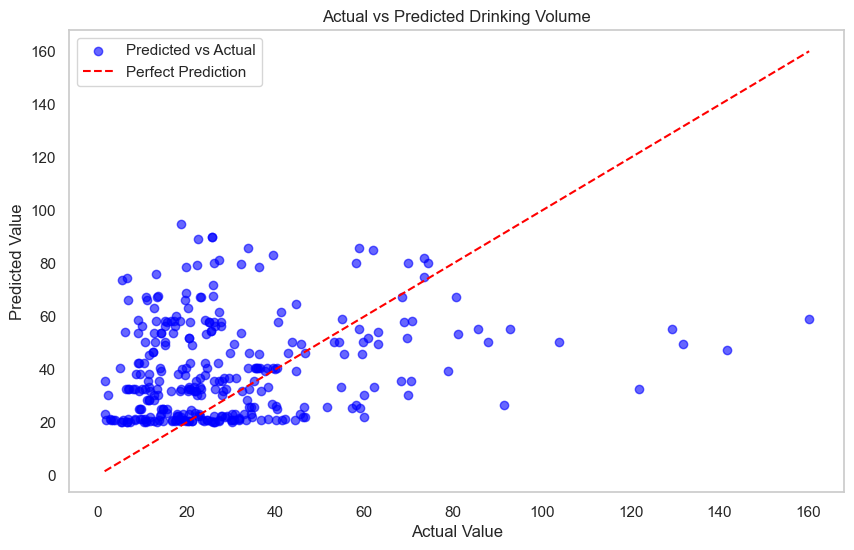

In [73]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

# Print evaluation metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df.head(50))
# Plot Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual vs Predicted Drinking Volume')
plt.legend()
plt.grid()
plt.show()

In [35]:
# plt.figure(figsize=(10, 6))
# plt.scatter(X, y, color='blue', label='Predicted vs Actual', alpha=0.6)
# # plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
# plt.xlabel('timestamp')
# plt.ylabel('Volume')
# plt.title('All data plot')
# plt.legend()
# plt.grid()
# plt.show()

Explained Variance by Principal Components:
Principal Component 1: 0.9767
Principal Component 2: 0.0233

Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 355.7899
Root Mean Squared Error (RMSE): 18.8624
R-squared (R²): -0.1313
Root Mean Squared Percentage Error (RMSPE): 50.8998%
     Actual  Predicted
252    36.0  30.683269
253    33.7  30.683269
254    23.0  33.581829
255    13.9  29.026949
256    17.7  28.612869


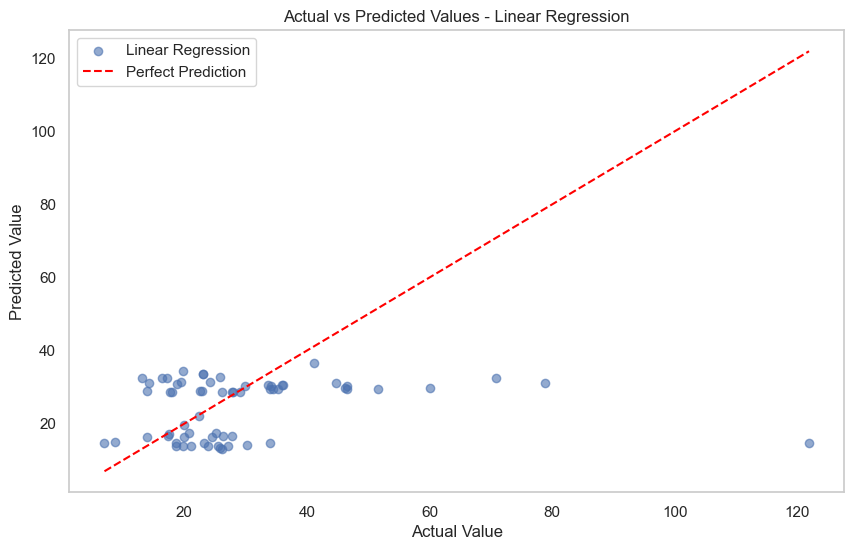


Support Vector Regression Evaluation Metrics:
Mean Squared Error (MSE): 392.2090
Root Mean Squared Error (RMSE): 19.8043
R-squared (R²): -0.2471
Root Mean Squared Percentage Error (RMSPE): 46.2566%
     Actual  Predicted
252    36.0  21.298874
253    33.7  21.298874
254    23.0  26.832326
255    13.9  19.694934
256    17.7  19.721885


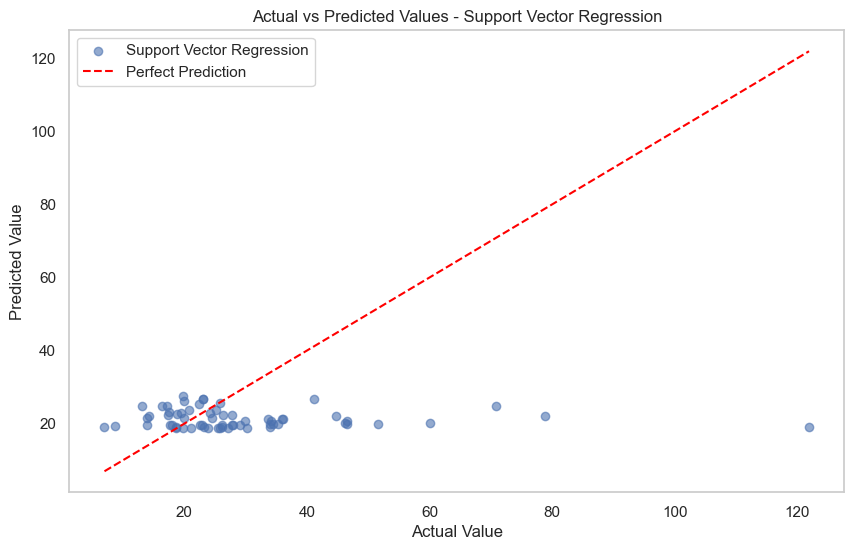


Decision Tree Evaluation Metrics:
Mean Squared Error (MSE): 460.9865
Root Mean Squared Error (RMSE): 21.4706
R-squared (R²): -0.4658
Root Mean Squared Percentage Error (RMSPE): 56.2749%
     Actual  Predicted
252    36.0  37.483333
253    33.7  37.483333
254    23.0  47.010137
255    13.9  17.749442
256    17.7  19.858975


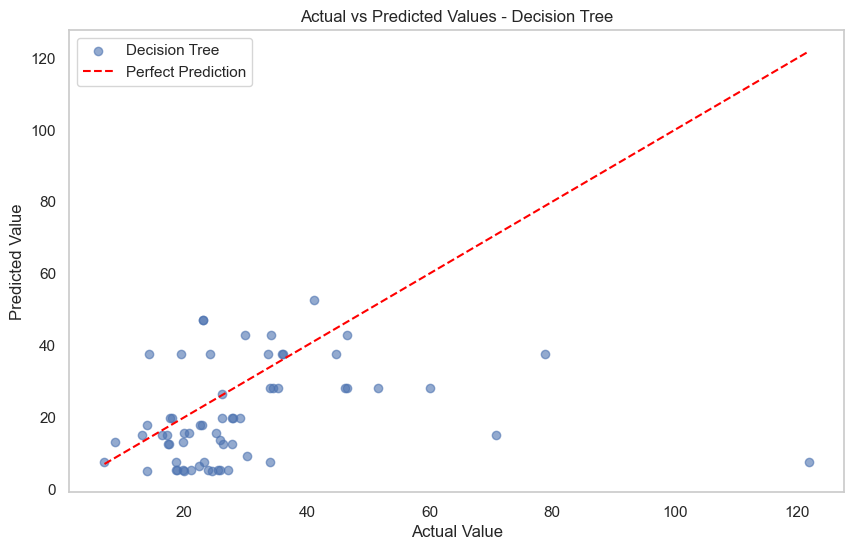


Random Forest Evaluation Metrics:
Mean Squared Error (MSE): 432.9140
Root Mean Squared Error (RMSE): 20.8066
R-squared (R²): -0.3765
Root Mean Squared Percentage Error (RMSPE): 53.0964%
     Actual  Predicted
252    36.0  37.607845
253    33.7  37.607845
254    23.0  41.942630
255    13.9  22.698017
256    17.7  23.624023


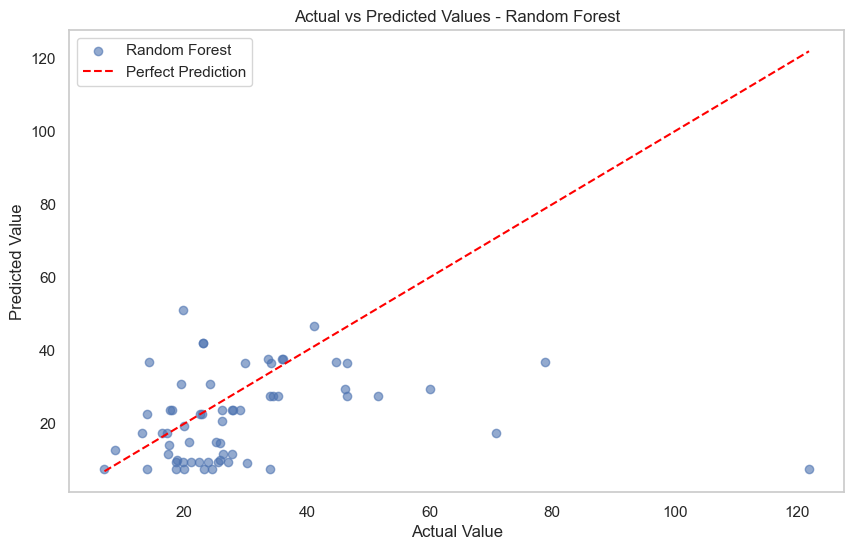


Gradient Boosting Evaluation Metrics:
Mean Squared Error (MSE): 418.2079
Root Mean Squared Error (RMSE): 20.4501
R-squared (R²): -0.3298
Root Mean Squared Percentage Error (RMSPE): 52.0294%
     Actual  Predicted
252    36.0  35.564754
253    33.7  35.564754
254    23.0  42.677422
255    13.9  21.433429
256    17.7  23.785197


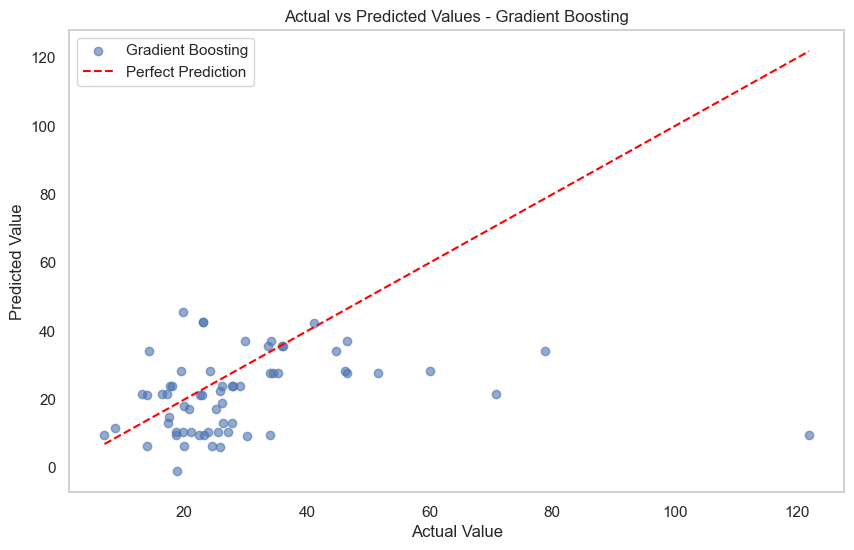


K-Nearest Neighbors Evaluation Metrics:
Mean Squared Error (MSE): 460.4357
Root Mean Squared Error (RMSE): 21.4578
R-squared (R²): -0.4640
Root Mean Squared Percentage Error (RMSPE): 52.4922%
     Actual  Predicted
252    36.0  37.680000
253    33.7  37.680000
254    23.0  40.705136
255    13.9   8.178872
256    17.7  16.752484


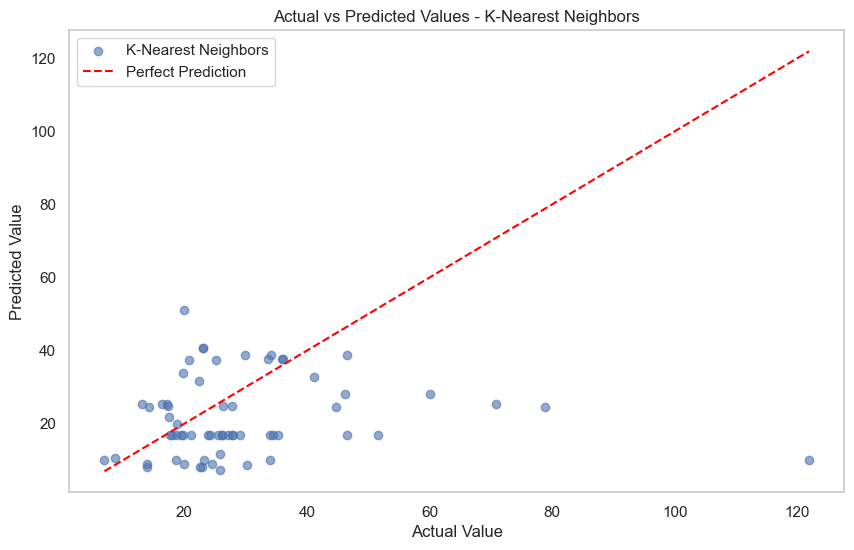


PCA Loadings:
                       PC1       PC2
time_steps        7.524272  0.047066
Container_Weight -0.304715  1.162196


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA

# Assuming X_train, X_test, y_train, y_test are already defined

# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

# Store evaluation results
results = {}

# Fit PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Print explained variance
print("Explained Variance by Principal Components:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i + 1}: {var:.4f}")

# Model evaluation
for model_name, model in models.items():
    # Fit the model
    model.fit(X_train_pca, y_train)

    # Make predictions
    y_pred = model.predict(X_test_pca)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

    # Store results in a dictionary
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'RMSPE': rmspe,
        'Predictions': y_pred
    }

    # Print evaluation metrics for the model
    print(f"\n{model_name} Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    # Create a comparison DataFrame for the first few rows
    comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
    print(comparison_df.head(5))

    # Plotting Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, label=model_name, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'Actual vs Predicted Values - {model_name}')
    plt.legend()
    plt.grid()
    plt.show()

# Analyzing Loadings of PCA

# Determine if X_train is a DataFrame or a NumPy array
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns
else:
    # If X_train is a NumPy array, you can use default feature names (e.g., "Feature 1", "Feature 2", ...)
    feature_names = [f'Feature {i+1}' for i in range(X_train.shape[1])]

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_df = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])], index=feature_names)

print("\nPCA Loadings:")
print(loading_df)

In [35]:
# Assuming X_train is your original feature set

# Fit PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Print explained variance
print("Explained Variance by Principal Components:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i + 1}: {var:.4f}")

# Analyzing Loadings of PCA

# Use the column names from the original DataFrame
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns.tolist()
else:
    # If it's a NumPy array, generate default names
    feature_names = [f'Feature {i + 1}' for i in range(X_train.shape[1])]

# Calculate the loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)  # Loadings calculated as explained variance
loading_df = pd.DataFrame(loadings, columns=[f'PC{i + 1}' for i in range(pca.components_.shape[0])], index=feature_names)

# Display peak contributions
print("\nPCA Loadings:")
print(loading_df)

# Optional: To better understand which features contribute to each component
print("\nContribution of Features to Principal Components (sorted):")
for i in range(loadings.shape[1]):
    print(f"Principal Component {i + 1}:")
    sorted_indices = np.argsort(np.abs(loadings[:, i]))[::-1]  # Sort by absolute value
    for index in sorted_indices:
        print(f"{feature_names[index]}: {loadings[index, i]:.4f}")

Explained Variance by Principal Components:
Principal Component 1: 0.9803
Principal Component 2: 0.0131

PCA Loadings:
                 PC1       PC2
time_steps  8.948601  0.092689
temp        0.188637  0.613849
sip_id     -1.129380  0.836950

Contribution of Features to Principal Components (sorted):
Principal Component 1:
time_steps: 8.9486
sip_id: -1.1294
temp: 0.1886
Principal Component 2:
sip_id: 0.8369
temp: 0.6138
time_steps: 0.0927


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

# Sample DataFrame with 4 features for demonstration
features = df[['time_steps', 'Gender', 'Container_Weight', 'temp', 'sip_id']]

# Optional: Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Fit PCA
pca = PCA(n_components=2)  # Adjust n_components as needed
X_pca = pca.fit_transform(features_scaled)

# Print explained variance
print("Explained Variance by Principal Components:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i + 1}: {var:.4f}")

# Loading results
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_df = pd.DataFrame(loadings, index=features.columns, columns=[f'PC{i + 1}' for i in range(loadings.shape[1])])

# Display PCA Loadings
print("\nPCA Loadings:")
print(loading_df)

# Contribution of Features to Principal Components
print("\nContribution of Features to Principal Components (sorted):")
for i in range(loadings.shape[1]):
    print(f"\nPrincipal Component {i + 1}:")
    sorted_indices = np.argsort(np.abs(loadings[:, i]))[::-1]  # Sort by absolute loading values
    for index in sorted_indices:
        print(f"{features.columns[index]}: {loadings[index, i]:.4f}")

# Optional: Visualize the PCA results
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, label='PCA Projection')
plt.title('PCA of Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid()
plt.legend()
plt.show()

KeyError: "['time_steps'] not in index"


Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 129.0847
Root Mean Squared Error (RMSE): 11.3615
R-squared (R²): 0.8243
Root Mean Squared Percentage Error (RMSPE): 33.9186%
    Actual  Predicted
56      80  94.622436
57      60  80.197723
58      40  57.733071
59      20  40.092382
60     100  89.441105


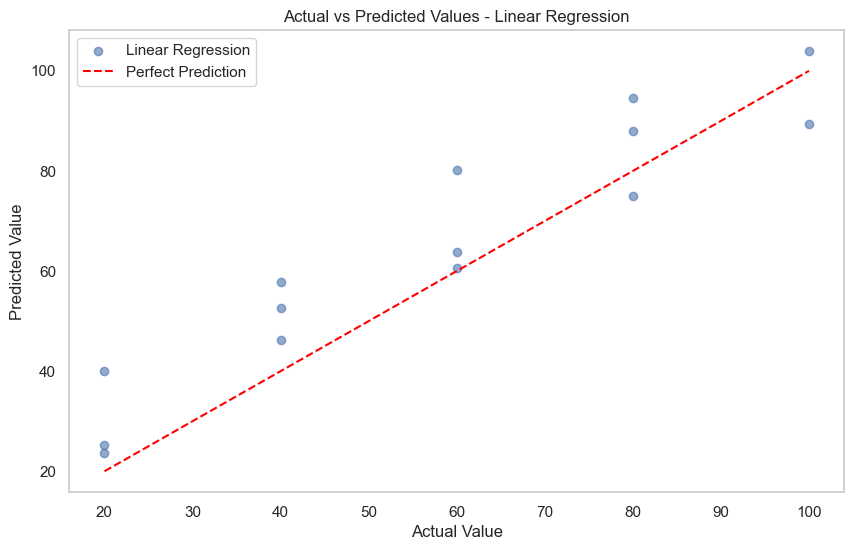


Support Vector Regression Evaluation Metrics:
Mean Squared Error (MSE): 420.9581
Root Mean Squared Error (RMSE): 20.5173
R-squared (R²): 0.4270
Root Mean Squared Percentage Error (RMSPE): 70.2413%
    Actual  Predicted
56      80  70.115554
57      60  69.535660
58      40  60.008501
59      20  50.441208
60     100  68.910601


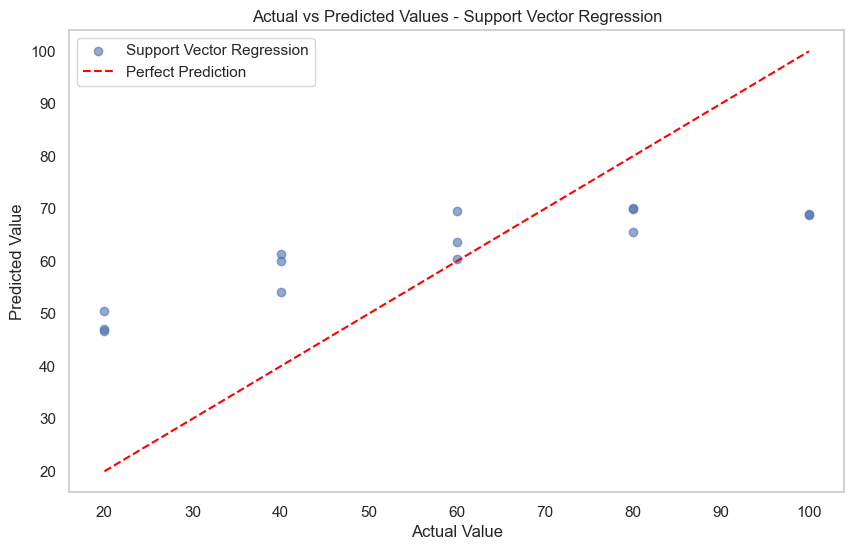


Decision Tree Evaluation Metrics:
Mean Squared Error (MSE): 200.0000
Root Mean Squared Error (RMSE): 14.1421
R-squared (R²): 0.7278
Root Mean Squared Percentage Error (RMSPE): 37.6650%
    Actual  Predicted
56      80      100.0
57      60       80.0
58      40       60.0
59      20       40.0
60     100      100.0


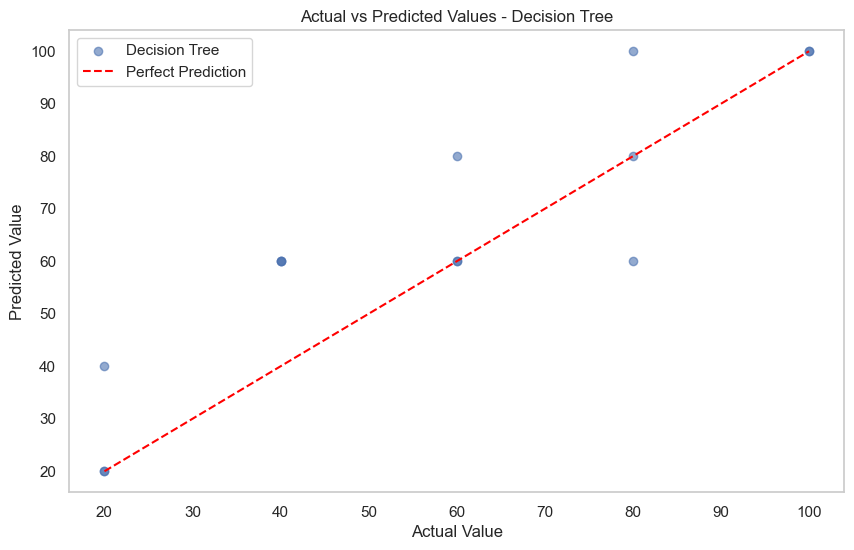


Random Forest Evaluation Metrics:
Mean Squared Error (MSE): 210.4914
Root Mean Squared Error (RMSE): 14.5083
R-squared (R²): 0.7135
Root Mean Squared Percentage Error (RMSPE): 38.8663%
    Actual  Predicted
56      80       95.4
57      60       86.8
58      40       64.8
59      20       39.6
60     100       93.8


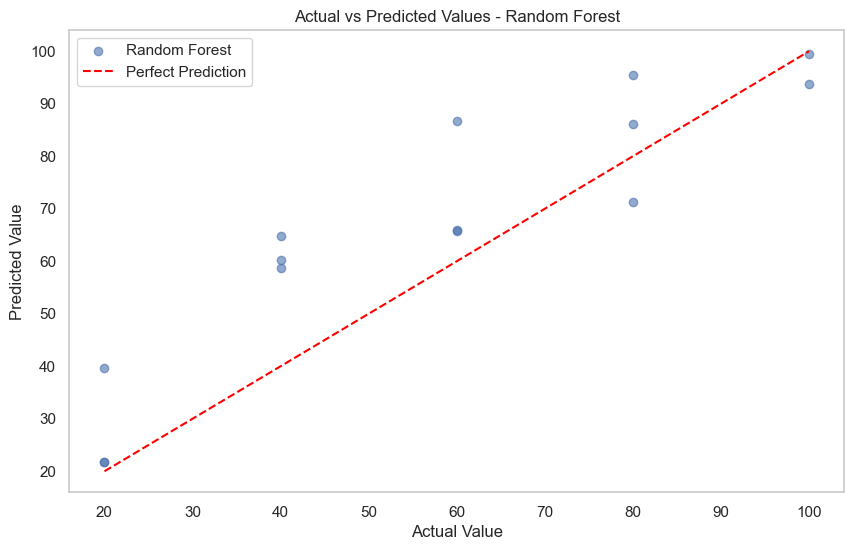


Gradient Boosting Evaluation Metrics:
Mean Squared Error (MSE): 308.5367
Root Mean Squared Error (RMSE): 17.5652
R-squared (R²): 0.5800
Root Mean Squared Percentage Error (RMSPE): 43.7671%
    Actual  Predicted
56      80  92.707881
57      60  96.188814
58      40  71.327165
59      20  40.255089
60     100  98.357223


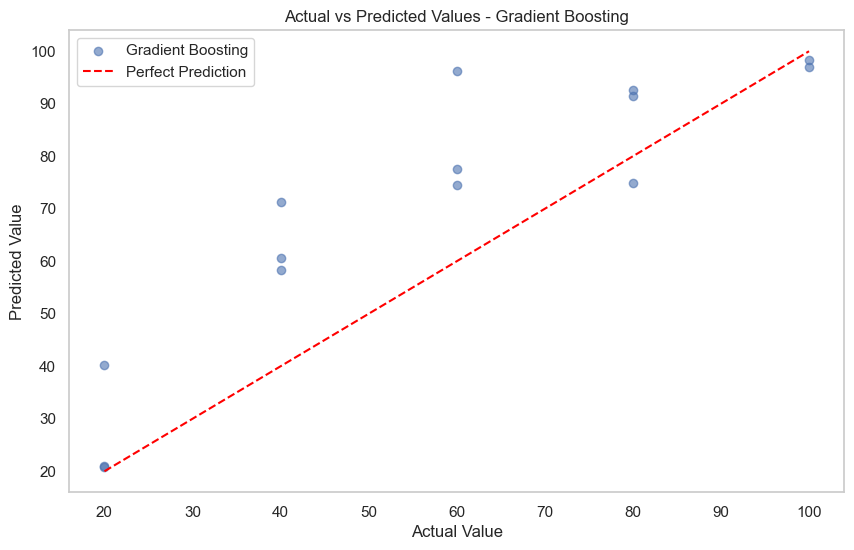


K-Nearest Neighbors Evaluation Metrics:
Mean Squared Error (MSE): 301.7143
Root Mean Squared Error (RMSE): 17.3699
R-squared (R²): 0.5893
Root Mean Squared Percentage Error (RMSPE): 48.4821%
    Actual  Predicted
56      80       92.0
57      60       80.0
58      40       72.0
59      20       44.0
60     100       88.0


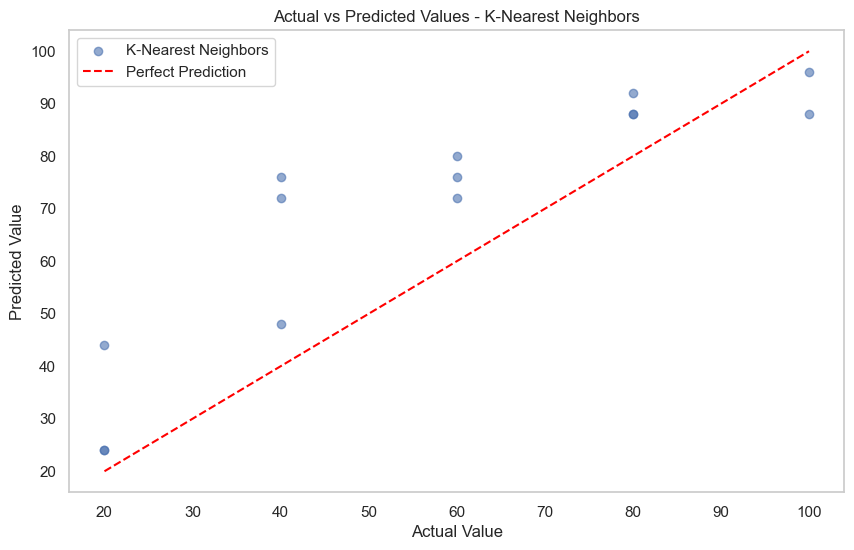

In [37]:
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    # "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

# Store evaluation results
results = {}

for model_name, model in models.items():
    # Fit the model
    from sklearn.decomposition import PCA

    pca = PCA(n_components=2)

    X_train = pca.fit_transform(X_train)
    X_test = pca.transform(X_test)
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

    # Store results in a dictionary
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'RMSPE': rmspe,
        'Predictions': y_pred
    }

    # Print evaluation metrics for the model
    print(f"\n{model_name} Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    # Create a comparison DataFrame for the first few rows
    comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
    print(comparison_df.head(5))

    # Plotting Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, label=model_name, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'Actual vs Predicted Values - {model_name}')
    plt.legend()
    plt.grid()
    plt.show()

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have already defined your models and results above
# color_map = {
#     0: 'blue',
#     1: 'orange',
#     2: 'green',
#     3: 'red',
#     4: 'purple'
# }
color_map = {
    0: 'blue',    # For 7.7
    1: 'orange',  # For 10.6
    2: 'green',   # For 10.9
    3: 'red',     # For 12.7
    4: 'purple',  # For 19.8
    5: 'cyan'     # For 359
}
# Store evaluation results
results = {}

for model_name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

    # Store results in a dictionary
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'RMSPE': rmspe,
        'Predictions': y_pred
    }

    # Print evaluation metrics for the model
    print(f"\n{model_name} Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Container_Weight': X_test['Container_Weight']})
    
    # Plotting Actual vs Predicted with Container Weights
    plt.figure(figsize=(10, 6))

    for weight, group in comparison_df.groupby('Container_Weight'):
        plt.scatter(group['Actual'], group['Predicted'], 
                    label=f'Container Weight: {weight}', 
                    color=color_map[weight], 
                    alpha=0.6)
# Assuming you use the updated color mapping provided above
# for weight, group in comparison_df.groupby('Container_Weight'):
#     plt.scatter(group['Actual'], group['Predicted'], 
#                 label=f'Container Weight: {weight}', 
#                 color=color_map[weight], 
#                 alpha=0.6)
    plt.plot([comparison_df['Actual'].min(), comparison_df['Actual'].max()],
             [comparison_df['Actual'].min(), comparison_df['Actual'].max()],
             color='black', ls='--', label='Perfect Prediction')

    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'Actual vs Predicted Values - {model_name}')
    plt.legend()
    plt.grid()
    plt.show()


Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 129.0847
Root Mean Squared Error (RMSE): 11.3615
R-squared (R²): 0.8243
Root Mean Squared Percentage Error (RMSPE): 33.9186%


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

# Assuming df is your DataFrame that contains 'Container_Weight' and your feature columns
# Mapping container weights to classes
df["Container_Weight"] = df["Container_Weight"].map({
    7.7: 0,
    10.6: 1,
    10.9: 1,  
    12.7: 2,
    19.8: 3,
    359: 4
})

# Assuming X_train and y_train are defined properly from your df DataFrame
# Define features and target variable
  # Replace with your actual target column name

# Store results for all model evaluations
overall_results = {}

# Get unique container weight classes
weight_classes = df["Container_Weight"].unique()

for category in weight_classes:
    # Filter data based on container weight class
    mask = df["Container_Weight"] == category
    X_filtered = X_train[mask]
    y_filtered = y_train[mask]

    if len(y_filtered) == 0:
        print(f"No data available for container weight category: {category}.")
        continue

    print(f"Training models for container weight category: {category}...")

    # Define your models
    models = {
        "Linear Regression": LinearRegression(),
        "Support Vector Regression": SVR(kernel='rbf'),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    }

    # Store evaluation results for this category
    results = {}

for category in weight_classes:
    # Filter data based on container weight class
    filtered_data = df[df["Container_Weight"] == category]
    
    # Check if the filtered data is not empty
    if len(filtered_data) == 0:
        print(f"No data available for container weight category: {category}.")
        continue

    # Split filtered data into features and target
    X_filtered = filtered_data[feature_columns]
    y_filtered = filtered_data[target_column]

    print(f"Training models for container weight category: {category}...")

    # Define your models
    models = {
        "Linear Regression": LinearRegression(),
        "Support Vector Regression": SVR(kernel='rbf'),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    }

    # Store evaluation results for this category
    results = {}

    for model_name, model in models.items():
        # Fit the model
        model.fit(X_filtered, y_filtered)

        # Make predictions using the filtered data
        y_pred = model.predict(X_filtered)  # Using the same filtered data for prediction

        # Calculate evaluation metrics
        mse = mean_squared_error(y_filtered, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_filtered, y_pred)
        rmspe = np.sqrt(np.mean(((y_filtered - y_pred) / y_filtered) ** 2)) * 100  # Percentage error

        # Store results in a dictionary
        results[model_name] = {
            'MSE': mse,
            'RMSE': rmse,
            'R^2': r2,
            'RMSPE': rmspe,
            'Predictions': y_pred
        }

        # Print evaluation metrics for the model
        print(f"\n{model_name} Evaluation Metrics for Container Weight Category {category}:")
        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"R-squared (R²): {r2:.4f}")
        print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

        # Create a comparison DataFrame for the first few rows
        comparison_df = pd.DataFrame({'Actual': y_filtered, 'Predicted': y_pred})
        print(comparison_df.head(5))

        # Plotting Actual vs Predicted
        plt.figure(figsize=(10, 6))
        plt.scatter(y_filtered, y_pred, label=model_name, alpha=0.6)
        plt.plot([y_filtered.min(), y_filtered.max()], [y_filtered.min(), y_filtered.max()], color='red', ls='--', label='Perfect Prediction')
        plt.xlabel('Actual Value')
        plt.ylabel('Predicted Value')
        plt.title(f'Actual vs Predicted Values - {model_name} (Container Weight {category})')
        plt.legend()
        plt.grid()
        plt.show()
    
    # Store results for overall overview
    overall_results[category] = results

print("Model evaluations completed for all container weight categories.")
    

/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_5529/4077206475.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Container_Weight"] = df["Container_Weight"].map({


IndexError: boolean index did not match indexed array along axis 0; size of axis is 56 but size of corresponding boolean axis is 1555

In [40]:
df["Container_Weight"]

212     NaN
213     NaN
214     NaN
215     NaN
216     NaN
         ..
20581   NaN
20582   NaN
20583   NaN
20584   NaN
20585   NaN
Name: Container_Weight, Length: 1555, dtype: float64

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor


# Models to evaluate
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

# # Define the category to filter
# category = 2  # Example category to filter by
# train_size = int(0.8 * len(grouped_data))  # 80% of the data for training
# X_train = X.iloc[:train_size]
# y_train = y.iloc[:train_size]
# X_test = X.iloc[train_size:]
# y_test = y.iloc[train_size:]
# # Filter X_train based on the Container_Weight column
# filtered_X = X_train[X_train["Container_Weight"] == category]
# print(filtered_X)
# # If you also want to filter the corresponding target variable y_train
# filtered_y = y_train.loc[filtered_X.index]
# print(filtered_y)
# filtered_X_test = X_test[X_test["Container_Weight"] == category]
# filtered_y_test = y_test.loc[filtered_X_test.index]
# print(filtered_X_test)
# print(filtered_y_test)
category = 1  # Example category to filter by

# Step 1: Filter X and y based on the Container_Weight column
filtered_X = X[X["Container_Weight"] == category]
filtered_y = y[filtered_X.index]  # Get matching y values using the indices of filtered_X

# Now filtered_X contains only the rows where Container_Weight equals the category
# filtered_y corresponds to these rows

# Step 2: Split the filtered data into train and test sets
train_size = int(0.8 * len(filtered_X))  # 80% for training
X_train = filtered_X.iloc[:train_size]
y_train = filtered_y.iloc[:train_size]
X_test = filtered_X.iloc[train_size:]
y_test = filtered_y.iloc[train_size:]

# Check if there are any rows after filtering
if filtered_X.empty or filtered_y.empty:
    print(f"No data available for container weight category: {category}.")
else:
    # Store evaluation results for this category
    results = {}

    for model_name, model in models.items():
        # Fit the model
        model.fit(X_train, y_train)

        # Make predictions using the filtered data
        y_pred = model.predict(X_test)  # Using the same filtered data for prediction

          # Calculate evaluation metrics
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

    # Store results in a dictionary
        results[model_name] = {
            'MSE': mse,
            'RMSE': rmse,
            'R^2': r2,
            'RMSPE': rmspe,
            'Predictions': y_pred
        }

    # Print evaluation metrics for the model
        print(f"\n{model_name} Evaluation Metrics:")
        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"R-squared (R²): {r2:.4f}")
        print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    # Create a comparison DataFrame for the first few rows
        comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
        print(comparison_df.head(5))

    # Plotting Actual vs Predicted
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred, label=model_name, alpha=0.6)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
        plt.xlabel('Actual Value')
        plt.ylabel('Predicted Value')
        plt.title(f'Actual vs Predicted Values - {model_name}')
        plt.legend()
        plt.grid()
        plt.show()

print("Model evaluations completed for container weight category:", category)

KeyError: 'Container_Weight'